# 🧠 **Student Depression Prediction — Improved ML Pipeline**


## **1. Install & Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier



## **2. Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Student Depression Dataset.csv to Student Depression Dataset.csv


In [4]:
df = pd.read_csv('Student Depression Dataset.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
df.shape

(27901, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [7]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


### There is no any null values

## **3. Exploratory Data Analysis (EDA)**

In [8]:
df['Depression'].value_counts()

,count
Depression,
1,16336
0,11565


In [9]:
print(f"\nClass balance: {df['Depression'].value_counts(normalize=True).round(3).to_dict()}")


Class balance: {1: 0.585, 0: 0.415}


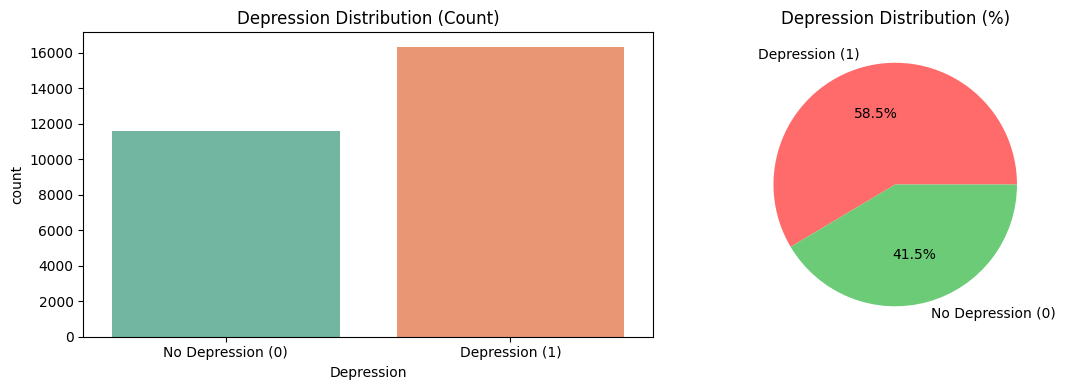

In [10]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Depression', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Depression Distribution (Count)')
axes[0].set_xticklabels(['No Depression (0)', 'Depression (1)'])

df['Depression'].value_counts().plot.pie(
    labels=['Depression (1)', 'No Depression (0)'],
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#6BCB77'],
    ax=axes[1]
)
axes[1].set_title('Depression Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

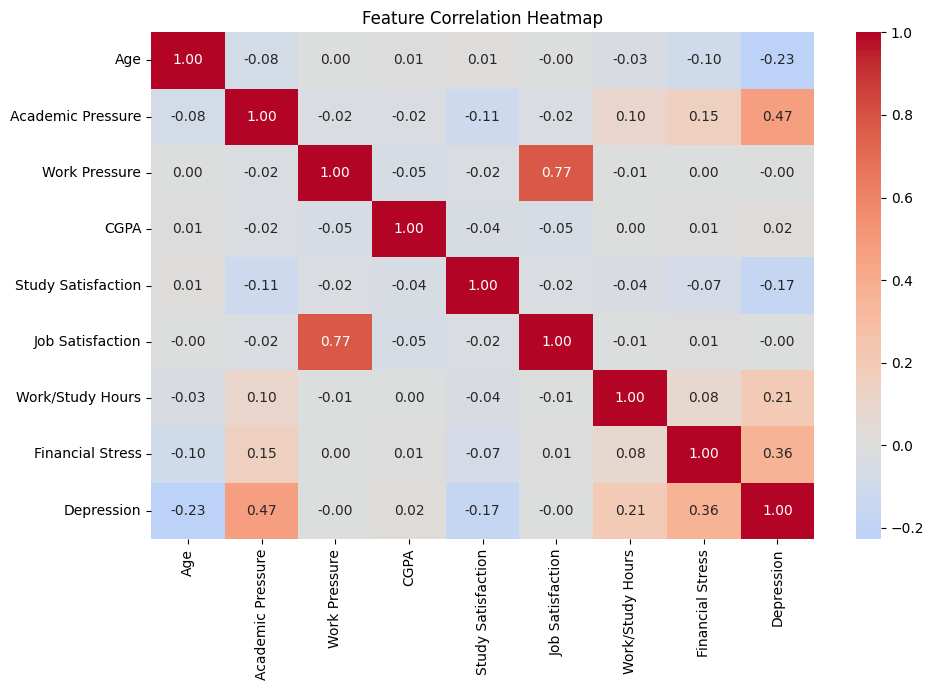

In [11]:
# Correlation heatmap for numerical features
numerical_preview = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                     'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                     'Financial Stress', 'Depression']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numerical_preview].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


### According to this heatmap when Academic Pressure increase Depresion is increase while age is negetively affected to it.

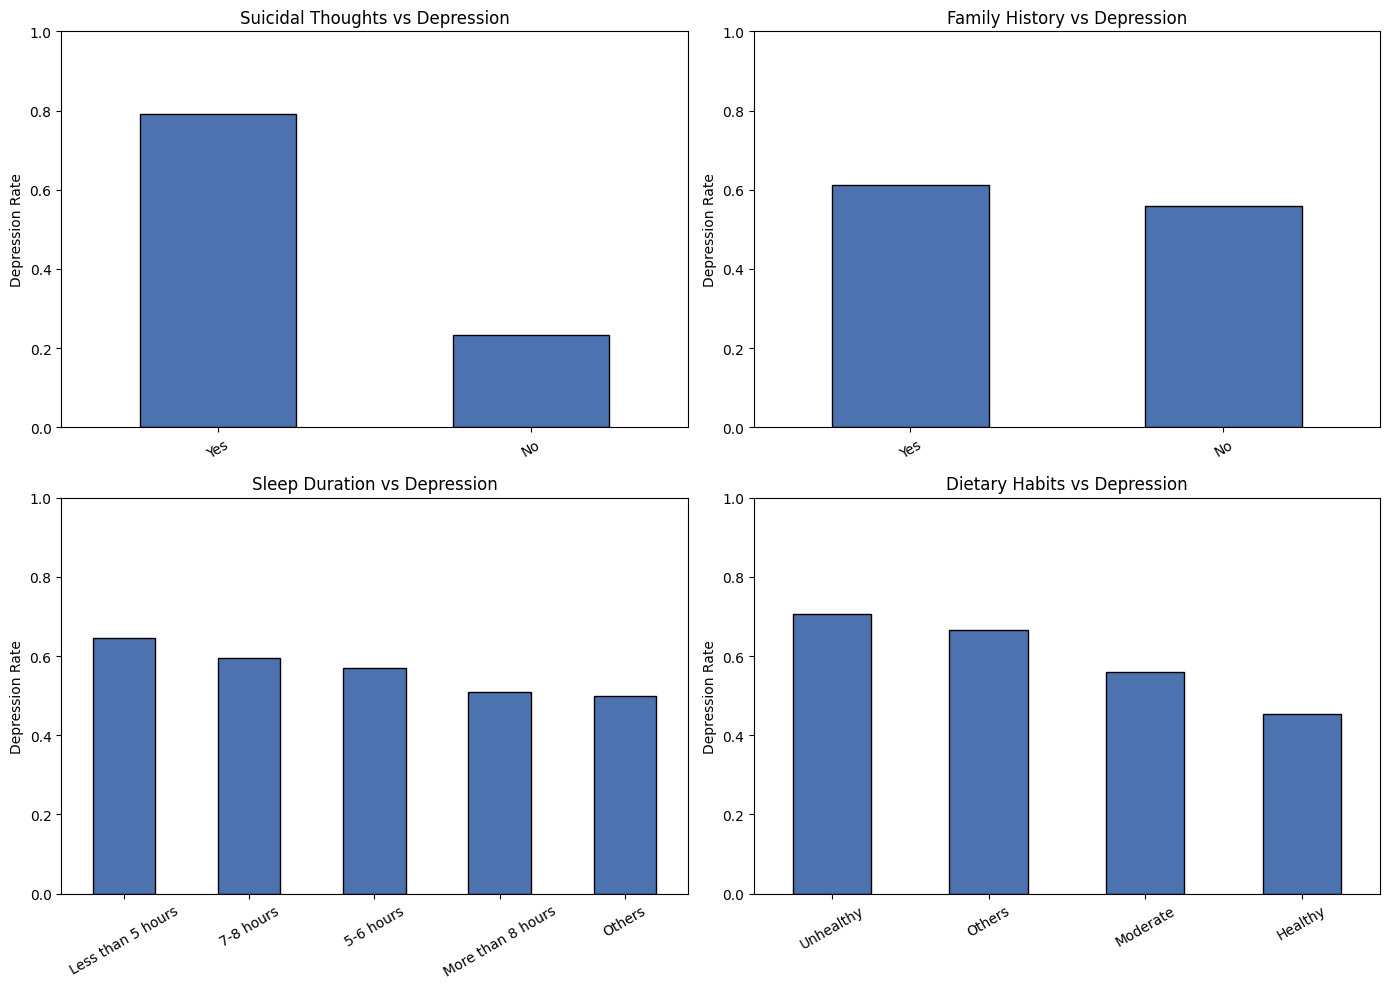

In [12]:
# Depression rate by key categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_features = [
    ('Have you ever had suicidal thoughts ?', 'Suicidal Thoughts vs Depression'),
    ('Family History of Mental Illness', 'Family History vs Depression'),
    ('Sleep Duration', 'Sleep Duration vs Depression'),
    ('Dietary Habits', 'Dietary Habits vs Depression')
]

for ax, (col, title) in zip(axes.flatten(), cat_features):
    ct = df.groupby(col)['Depression'].mean().sort_values(ascending=False)
    ct.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Depression Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## **4. Feature Engineering & Preprocessing**

Drop columns that don't carry predictive value
'id' is just a row number; 'City' and 'Degree' have too many categories with low signal
'Profession' kept since Student vs non-student may matter

In [13]:
drop_cols = ['id', 'City', 'Degree']
df_model = df.drop(columns=drop_cols)

In [14]:
# Define features and target
X = df_model.drop(columns=['Depression'])
y = df_model['Depression']

In [15]:
print("Features used:", X.columns.tolist())
print("Total features:", X.shape[1])

Features used: ['Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Total features: 14


In [17]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
Categorical columns: ['Gender', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [18]:
# IMPROVEMENT: Added StandardScaler to numerical pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # handles 3 missing values in Financial Stress
    ('scaler', StandardScaler())                  # normalizes numerical features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor built ✅")


Preprocessor built ✅


## **5. Train/Test Split**

In [19]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y  # stratify ensures balanced split
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_valid.shape[0]} samples")

Training set: 22320 samples
Validation set: 5581 samples


## **6. Baseline — Random Forest**

In [20]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=0))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, rf_preds)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, rf_preds, target_names=['No Depression', 'Depression']))

Random Forest Accuracy: 0.8346

Classification Report:
               precision    recall  f1-score   support

No Depression       0.82      0.78      0.80      2313
   Depression       0.85      0.88      0.86      3268

     accuracy                           0.83      5581
    macro avg       0.83      0.83      0.83      5581
 weighted avg       0.83      0.83      0.83      5581



## **7. XGBoost with Hyperparameter Tuning**

In [21]:
# IMPROVEMENT: Hyperparameter tuning with RandomizedSearchCV

xgb_base = XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight
=11565/16336)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_base)
])

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 4, 5, 6],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}


In [22]:
random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,           # try 20 random combinations
    cv=3,
    scoring='accuracy',
    random_state=0,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Academic '
                                                                                'Pressure',
                                                                                'Work '
                                                                                'Pressure',
                                                                                'CGPA',
                                                                                'Study '
                                                                                'Satisfaction',
                                                                                'Job '
                                                                                'Satisfaction',
                                                                                'Work/Study '
                                                                                'Hours',
                                                                                'Financial '
                                                                                'Stress']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                S...
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=0, scoring='accuracy', verbose=1)

In [23]:
print("\nBest parameters found:")
print(random_search.best_params_)
print(f"\nBest CV Accuracy: {random_search.best_score_:.4f}")


Best parameters found:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best CV Accuracy: 0.8458


In [24]:
# Evaluate best XGBoost model on validation set
best_xgb_pipeline = random_search.best_estimator_
xgb_preds = best_xgb_pipeline.predict(X_valid)

xgb_accuracy = accuracy_score(y_valid, xgb_preds)  # IMPROVEMENT: dynamic, not hardcoded
print(f"XGBoost (Tuned) Accuracy: {xgb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, xgb_preds, target_names=['No Depression', 'Depression']))

XGBoost (Tuned) Accuracy: 0.8393

Classification Report:
               precision    recall  f1-score   support

No Depression       0.79      0.83      0.81      2313
   Depression       0.87      0.85      0.86      3268

     accuracy                           0.84      5581
    macro avg       0.83      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581



## **8. Cross-Validation**

In [25]:
# Cross-validate the best XGBoost model on full data
cv_scores = cross_val_score(best_xgb_pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-Validation Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print("\n✔ Model is stable and not overfitting" if cv_scores.std() < 0.02 else "\n⚠ High variance — consider more regularization")


Cross-Validation Scores: [0.84   0.8416 0.8441 0.841  0.8491]
Mean CV Accuracy: 0.8432
Std Dev: 0.0033

✔ Model is stable and not overfitting


## **9. Visualizations**

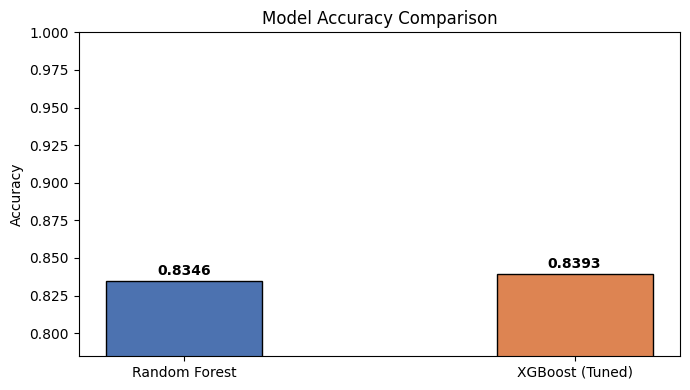

In [26]:
# Model comparison — IMPROVEMENT: dynamic scores, not hardcoded
model_names = ['Random Forest', 'XGBoost (Tuned)']
model_scores = [rf_accuracy, xgb_accuracy]

colors = ['#4C72B0' if s < max(model_scores) else '#DD8452' for s in model_scores]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, model_scores, color=colors, edgecolor='black', width=0.4)
plt.ylim(min(model_scores) - 0.05, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

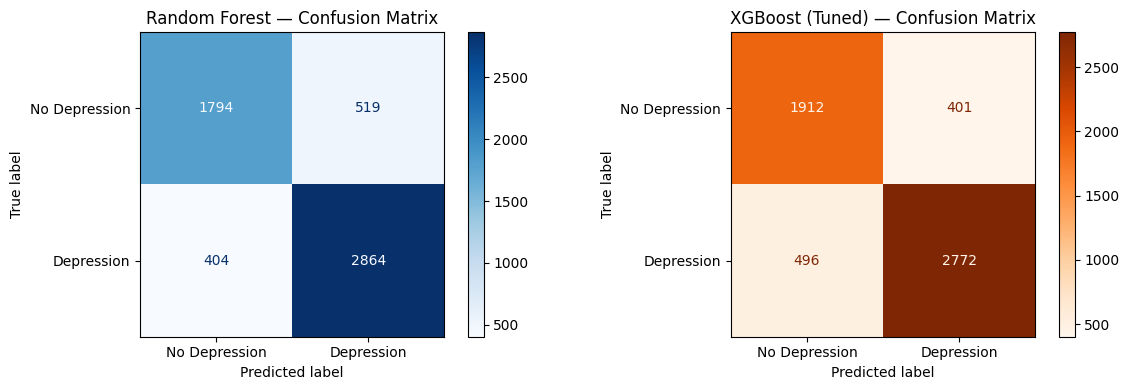

In [27]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_valid, rf_preds,
    display_labels=['No Depression', 'Depression'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Random Forest — Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_valid, xgb_preds,
    display_labels=['No Depression', 'Depression'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('XGBoost (Tuned) — Confusion Matrix')

plt.tight_layout()
plt.show()

In [28]:
# IMPROVEMENT: Feature importance from the correct model (XGBoost, not RF)
xgb_model = best_xgb_pipeline.named_steps['model']
xgb_preprocessor = best_xgb_pipeline.named_steps['preprocessor']

In [29]:
# Get feature names after preprocessing
feature_names = xgb_preprocessor.get_feature_names_out()
importances = xgb_model.feature_importances_

importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)


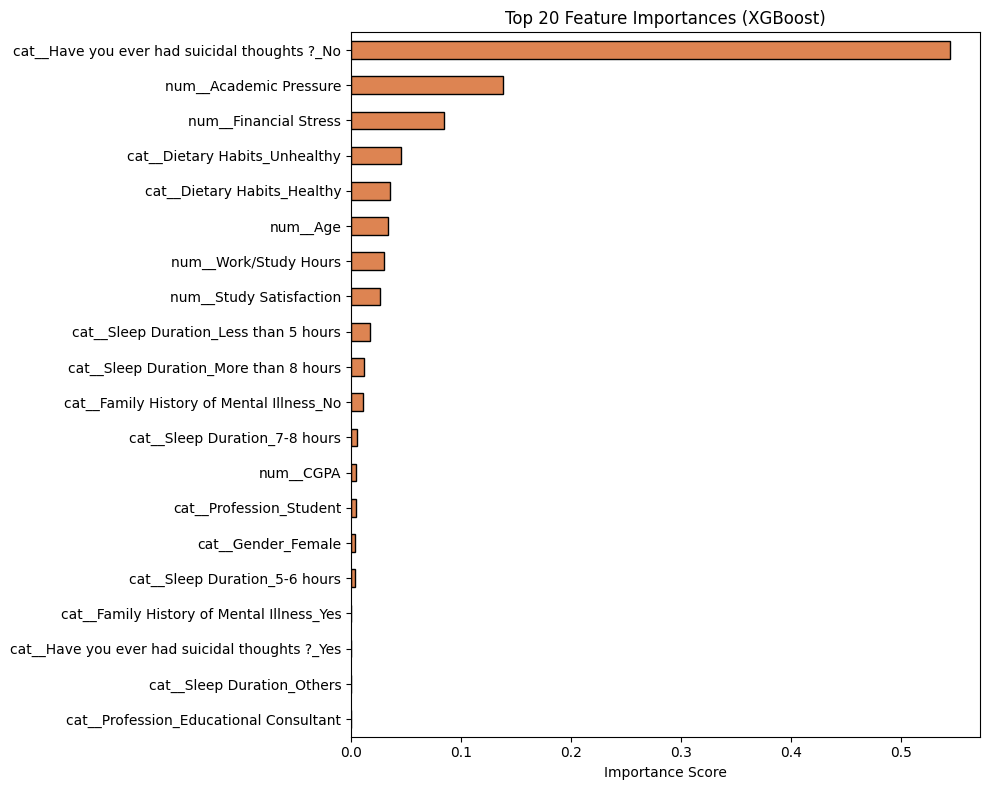

In [30]:
# Show top 20 most important features
top20 = importance_df.tail(20)

plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color='#DD8452', edgecolor='black')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

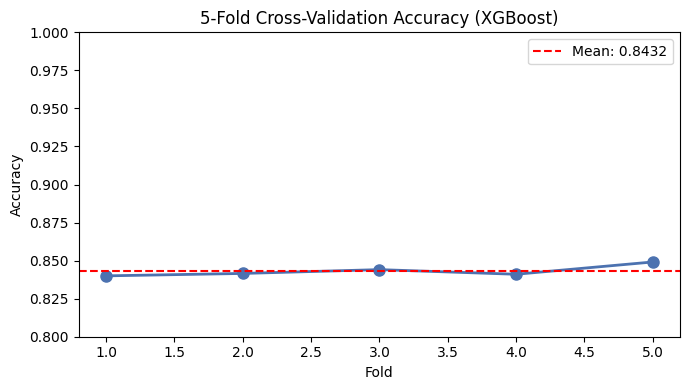

In [31]:
# Cross-validation score plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), cv_scores, marker='o', color='#4C72B0', linewidth=2, markersize=8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation Accuracy (XGBoost)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


## **10. Save Final Model**

In [32]:
# Retrain best model on FULL dataset before saving
final_model = best_xgb_pipeline
final_model.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Academic Pressure',
                                                   'Work Pressure', 'CGPA',
                                                   'Study Satisfaction',
                                                   'Job Satisfaction',
                                                   'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oneh...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [33]:
joblib.dump(final_model, 'student_depression_model_v2.pkl')
print("Model saved as 'student_depression_model_v2.pkl' ✅")

Model saved as 'student_depression_model_v2.pkl' ✅


## **11. Prediction Function**

In [34]:
def predict_depression(input_dict):
    """
    Predict depression from a dictionary of feature values.

    Example input:
    {
        'Gender': 'Female', 'Age': 22.0, 'Profession': 'Student',
        'Academic Pressure': 4.0, 'Work Pressure': 0.0, 'CGPA': 6.5,
        'Study Satisfaction': 2.0, 'Job Satisfaction': 0.0,
        'Sleep Duration': 'Less than 5 hours', 'Dietary Habits': 'Unhealthy',
        'Have you ever had suicidal thoughts ?': 'Yes',
        'Work/Study Hours': 8.0, 'Financial Stress': 4.0,
        'Family History of Mental Illness': 'Yes'
    }
    """
    input_df = pd.DataFrame([input_dict])
    prediction = final_model.predict(input_df)[0]
    probability = final_model.predict_proba(input_df)[0]
    label = "Depression Detected" if prediction == 1 else "No Depression Detected"
    print(f"Prediction: {label}")
    print(f"Confidence: {max(probability)*100:.1f}%")
    return prediction


In [35]:
# Example usage
sample = {
    'Gender': 'Female',
    'Age': 22.0,
    'Profession': 'Student',
    'Academic Pressure': 4.0,
    'Work Pressure': 0.0,
    'CGPA': 6.5,
    'Study Satisfaction': 2.0,
    'Job Satisfaction': 0.0,
    'Sleep Duration': 'Less than 5 hours',
    'Dietary Habits': 'Unhealthy',
    'Have you ever had suicidal thoughts ?': 'Yes',
    'Work/Study Hours': 8.0,
    'Financial Stress': 4.0,
    'Family History of Mental Illness': 'Yes'
}

predict_depression(sample)

Prediction: Depression Detected
Confidence: 97.7%


np.int64(1)

## **12. Final Summary**

**Key improvements over v1:**
1. Increased features from 6 → 14 (all relevant columns)
2. Added `StandardScaler` to numerical pipeline
3. Added `RandomizedSearchCV` for hyperparameter tuning
4. Fixed feature importance to use XGBoost (not Random Forest)
5. Accuracy scores computed dynamically (not hardcoded)
6. Added confusion matrix visualization
7. Added `stratify=y` to train/test split for balanced classes
8. Prediction function returns probability alongside class label

In [36]:
from google.colab import files
files.download('student_depression_model_v2.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>